In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# Resolve path to processed data
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_tracks.parquet"

df = pd.read_parquet(DATA_PATH)
print(f"Loaded dataset shape {df.shape}")
df.head()

Loaded dataset shape (50000, 24)


,id,track_name,album,album_id,artist_name,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,3JIQkAbOp9SYcEa0nagx9J,Beating Heart,Born Again,4ENGT5gflpjjj6xytmpslI,['Backseat Virgins'],['4iOrDXromixOj7es03IQ8I'],5,1,True,0.288,...,0.0558,0.000398,0.000046,0.0564,0.839,190.685,66733,4.0,2020,2020-01-01
1,1raCnpOJhPkUj0ZhRnYFIE,Terpsichore: Ballet - Ballet des Amazones,Widmann: Musicalischer Tugendtspiegel - Praeto...,73bv1mF7DN6cvpDgtjNnjW,"['Michael Praetorius', 'Accademia Del Ricercar...","['0OTPgUKkDp058dC3czXFM2', '367LrJPcTcGbWL2WdK...",16,1,False,0.203,...,0.0407,0.981000,0.640000,0.1060,0.133,129.727,155173,4.0,2016,2016-11-06
2,3mq4dsFzaDBmLsc2DNSvUD,Took Out A Loan,Baby 81,6LwDQs1eEiLdVmKSKL9Xlw,['Black Rebel Motorcycle Club'],['1tpXaFf2F55E7kVJON4j4G'],1,1,False,0.444,...,0.0460,0.014200,0.017500,0.3370,0.507,100.194,255173,4.0,2007,2007-04-27
3,6AhhFZrtbahGPOkzJGVOIV,Do You Hear What I Hear?,Christmas Is...,5OG6zx5V9HLP0L5NxmVD4k,['Percy Faith & His Orchestra & Chorus'],['1s8NQxAEct8j8JZT05CIUu'],10,1,False,0.316,...,0.0300,0.740000,0.606000,0.2460,0.295,101.147,167293,4.0,1966,1966
4,45TZv5gYupS3UoZf3jlias,El Gavilancito,Veracruz - Serie Musical de México - Conjunto ...,7xNuUQU7D5xHk65qKvFddp,['Conjunto Jarocho Medellin De Lino Chavez'],['4k2xuriA3VQDaaWv4ojFBq'],10,1,False,0.418,...,0.0488,0.818000,0.022000,0.3780,0.974,193.811,139413,3.0,2004,2004-09-27


In [2]:
audio_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "valence", "tempo"
]

# Check summary statistics (distributions, min/max, percentiles)
df[audio_cols].describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
danceability,0.492493,0.189478,0.05420,0.4990,0.986
energy,0.507609,0.295031,0.00002,0.5220,1.000
loudness,-11.840386,6.968919,-54.49300,-9.8160,-0.014
speechiness,0.084468,0.115083,0.02220,0.0449,0.962
acousticness,0.449809,0.386348,0.00000,0.3960,0.996
instrumentalness,0.287512,0.377363,0.00000,0.0103,1.000
valence,0.426698,0.270508,0.00000,0.4000,0.997
tempo,117.745515,30.569143,30.01800,116.5310,246.130


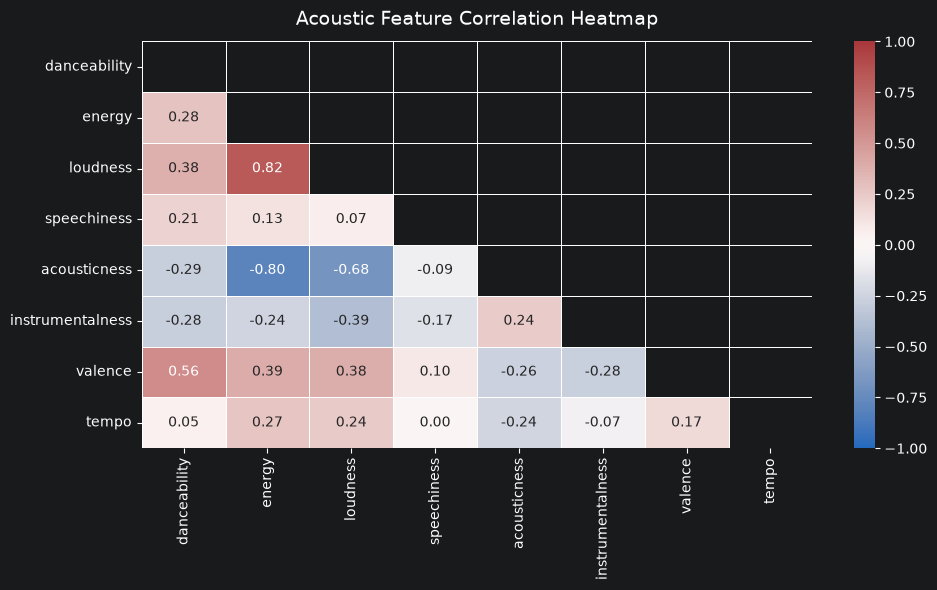

In [5]:
plt.figure(figsize=(10, 6))
corr = df[audio_cols].corr()

# Mask the upper triangle for visual clarity
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Acoustic Feature Correlation Heatmap", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

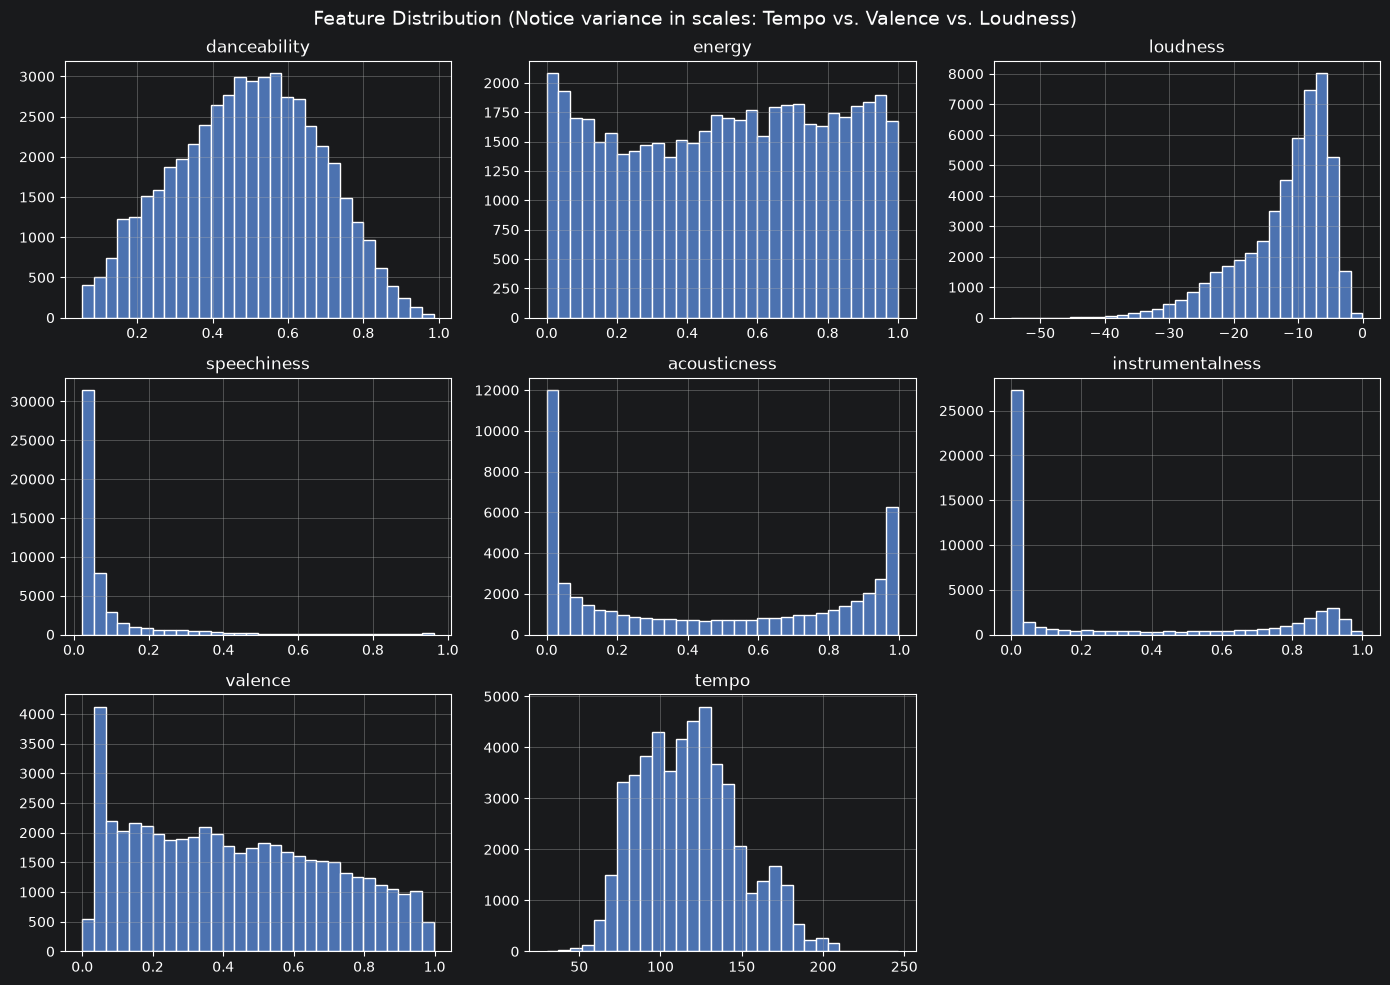

In [7]:
# Visualize distributions to understand why StandardScaler is necessary
df[audio_cols].hist(bins=30, figsize=(14, 10), layout=(3, 3), color="#4C72B0", edgecolor="white")
plt.suptitle("Feature Distribution (Notice variance in scales: Tempo vs. Valence vs. Loudness)", fontsize=14)
plt.tight_layout()
plt.show()